In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve


In [2]:
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')

## Remove Nulls & Drops Irrelevent Columns

In [3]:
# Where housing is missing, loan is missing
# Remove those rows
df = df[(df['housing'] != 'unknown') & (df['loan'] != 'unknown')]
# Drop jobs unknowns
df = df[df['job'] != 'unknown']
df = df[df['marital'] != 'unknown']
# Drop jobs unknowns
df = df[df['education'] != 'unknown']
cols_to_drop = ['default', 'duration', 'previous', 'pdays' ]
df.drop(columns=cols_to_drop, inplace=True)

## Defining Variables

In [4]:
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

## Train-Test Splitting

In [5]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Why Do We Scale Features?

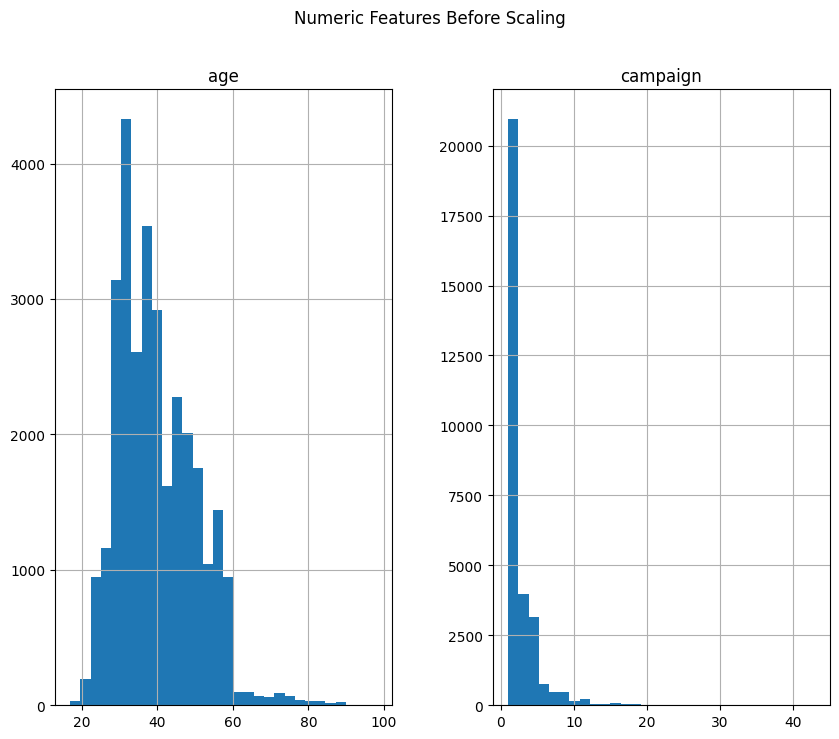

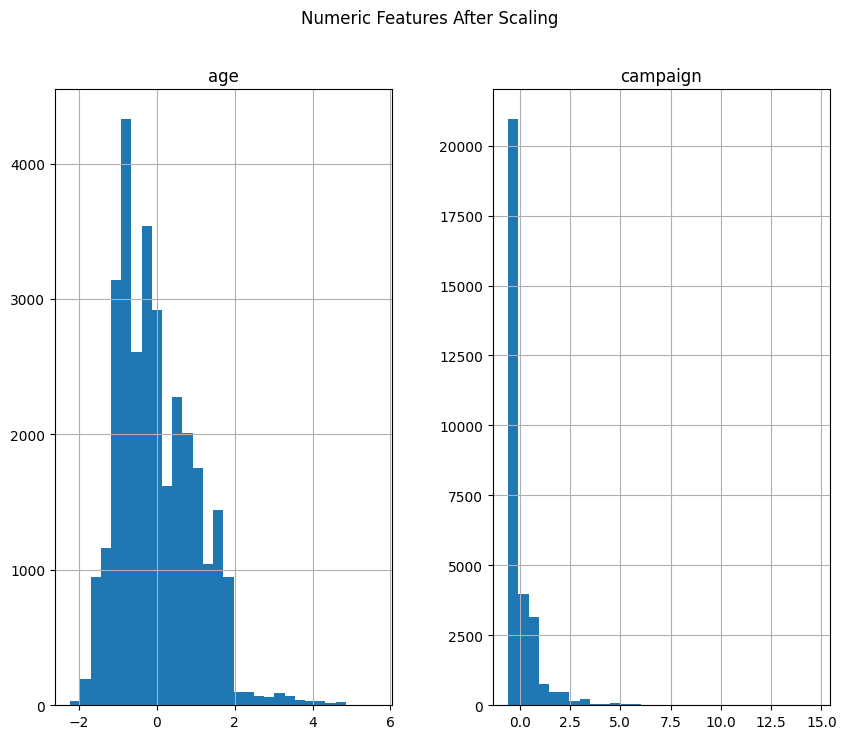

In [6]:
numeric_cols = ['age', 'campaign']

X_train_log[numeric_cols].hist(bins=30, figsize=(10, 8))
plt.suptitle('Numeric Features Before Scaling')
plt.show()

# After scaling
scaler = StandardScaler()
scaled = scaler.fit_transform(X_train_log[numeric_cols])
pd.DataFrame(scaled, columns=numeric_cols).hist(bins=30, figsize=(10, 8))
plt.suptitle('Numeric Features After Scaling')
plt.show()

Since some numerical features can be heavily skewed, like 'age' and 'campaign', this can make logistic regression highly sensitive to how these features can be scaled, as features with large scales could potentially dominate the regression process. By adjusting the values on the axes, which is a key aspect of scaling, we can ensure that each feature is on a reasonable scale and the model will converge reliably without any hiccups, despite the overall shape of the distribution appearing to have not changed much.

## Defining Categorical and Numeric Columns

In [7]:
categorical_cols = [
    'job', 'marital', 'education', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome']


numeric_cols = [c for c in X.columns if c not in categorical_cols]

## Constructing Pipelines

In [8]:
# Numeric Columns
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Columns
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combining the Two
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Making the Full Pipeline
log_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

## Training the Data (Fitting the Pipeline)

In [9]:
log_pipeline.fit(X_train_log, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

## Predicting

In [10]:
y_pred_log = log_pipeline.predict(X_test_log)
y_prob_log = log_pipeline.predict_proba(X_test_log)[:, 1]

## Evaluating the Model (Confusion Matrix, ROC-AUC Scores)

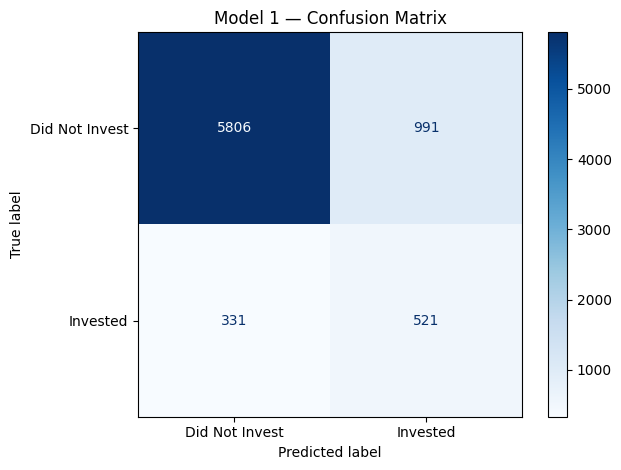

                precision    recall  f1-score   support

Did Not Invest       0.95      0.85      0.90      6797
      Invested       0.34      0.61      0.44       852

      accuracy                           0.83      7649
     macro avg       0.65      0.73      0.67      7649
  weighted avg       0.88      0.83      0.85      7649



In [11]:
cm = confusion_matrix(y_test_log, y_pred_log)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Invest', 'Invested'])
disp_base.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()
print(classification_report(y_test_log, y_pred_log, target_names=['Did Not Invest', 'Invested']))

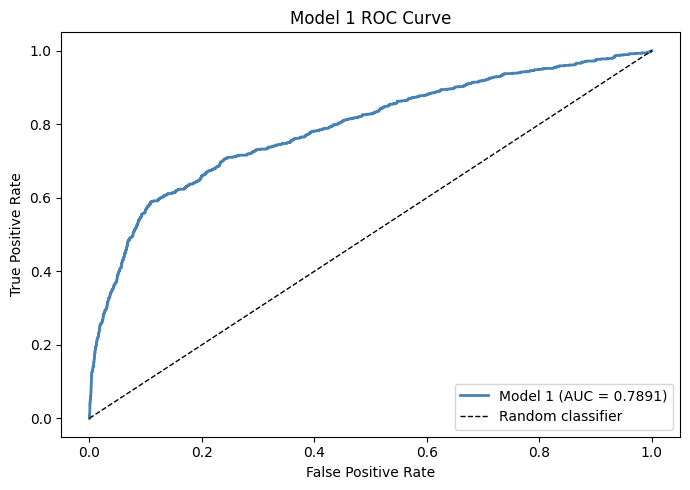

Model 1 ROC-AUC: 0.7891


In [12]:
fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)
auc = roc_auc_score(y_test_log, y_prob_log)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc:.4f}")

From what we can see, the model is picking up potential investors, but it still missing out on a large number of investors through misidentifcation. Mislabeling someone who isn't going to invest as a potential investor isn't great either, but it isn't as concerning as labeling a potential investor as someone not worth targeting. As a result, we need to re-tune the model to be more accurate at labeling future investors.

## Identifying the Top Positive and Negative Coefficients

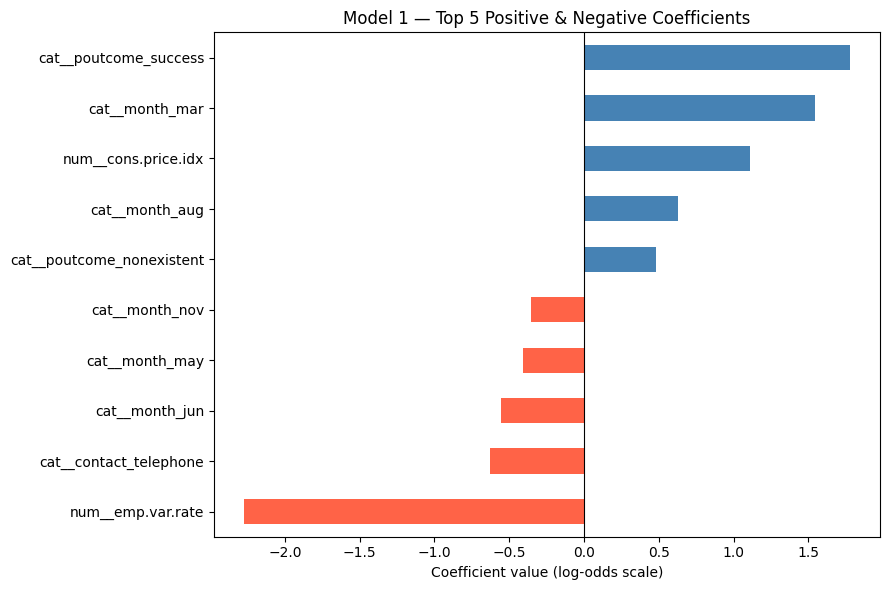

In [13]:
feature_names = log_pipeline.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(
    log_pipeline.named_steps['model'].coef_[0],
    index=feature_names
).sort_values()

# Show top 10 positive and top 10 negative
top_coefs = pd.concat([coefs.head(5), coefs.tail(5)])
top_coefs.plot(kind='barh', figsize=(9, 6), color=top_coefs.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Model 1 — Top 5 Positive & Negative Coefficients')
plt.xlabel('Coefficient value (log-odds scale)')
plt.tight_layout()
plt.show()

## Lowering the Threshold of our Model

In [14]:
threshold = 0.35
y_pred_log_tuned = (y_prob_log >= threshold).astype(int)

## Re-Evaulating Our Model

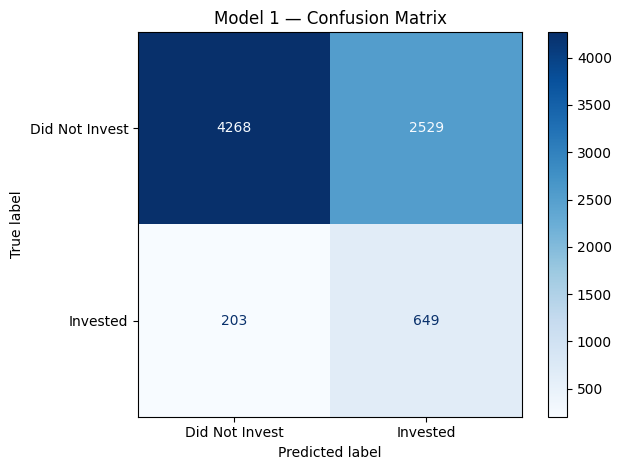

                precision    recall  f1-score   support

Did Not Invest       0.95      0.63      0.76      6797
      Invested       0.20      0.76      0.32       852

      accuracy                           0.64      7649
     macro avg       0.58      0.69      0.54      7649
  weighted avg       0.87      0.64      0.71      7649



In [15]:
cm_tune = confusion_matrix(y_test_log, y_pred_log_tuned)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_tune, display_labels=['Did Not Invest', 'Invested'])
disp_base.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()
print(classification_report(y_test_log, y_pred_log_tuned, target_names=['Did Not Invest', 'Invested']))

We've dramatically lowered the number of potential investors we've missed out on, however it did come at the cost of lowering the precision of identifying these potential investors. Nonetheless, we are able to encapsulate more investors by lowering the threshold of our model.

## Precision-Recall Curve For Better Understanding

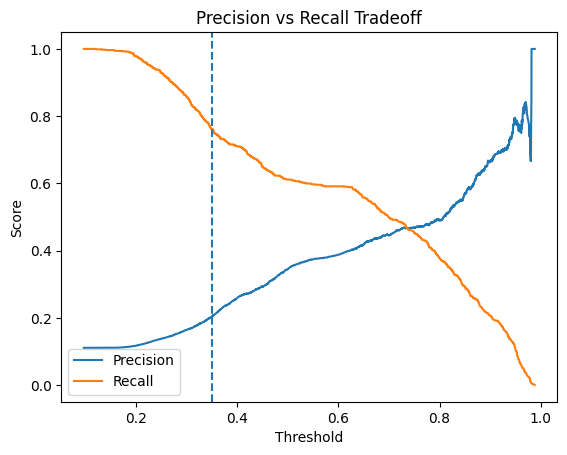

In [16]:
precisions, recalls, thresholds = precision_recall_curve(y_test_log, y_prob_log)

plt.figure()
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall Tradeoff')
plt.axvline(x=0.35, linestyle='--')
plt.legend()
plt.show()

## Comparing the Two Models

In [17]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate(y_test_log, y_pred_log, "Default (0.5)")
evaluate(y_test_log, y_pred_log_tuned, "Tuned (0.35)")


Default (0.5)
[[5806  991]
 [ 331  521]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      6797
           1       0.34      0.61      0.44       852

    accuracy                           0.83      7649
   macro avg       0.65      0.73      0.67      7649
weighted avg       0.88      0.83      0.85      7649


Tuned (0.35)
[[4268 2529]
 [ 203  649]]
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      6797
           1       0.20      0.76      0.32       852

    accuracy                           0.64      7649
   macro avg       0.58      0.69      0.54      7649
weighted avg       0.87      0.64      0.71      7649



As we can see, lowering the threshold does in fact increase the recall of the model, however we don't want to sacrifice too much precision by doing so, as that would just make the model redundant. By only slightly lowering the threshold to 0.35, we've included over 125 more likely investors, without mislabeling too many people that weren't going to invest as potential investors.

## GridSearchCV Tuning

Now that we have established a baseline for our model with a threshold of 0.35, we want to tune the hyperparameters for our logistic regression model. By using GridSearchCV, we aren't going to just randomly guess what to tune the paramters to, instead, GridSearchCV allows us to test different combinations using cross-validation and select the model configuration that maximizes our recall since we want to capture as many potential investors as possible. 

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.05, 0.1, 0.5, 1, 5],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__penalty': ['l2']
}

grid_search = GridSearchCV(
    log_pipeline,
    param_grid,
    cv=5,
    scoring='recall',       # Using scoring as recall to prioritize catching positives
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_log, y_train_log)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validated Recall: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/ethanooi/Documents/ML/ML1_final/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ethanooi/Documents/ML/ML1_final/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ethanooi/Documents/ML/ML1_final/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was d

Best Parameters: {'model__C': 0.05, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Cross-Validated Recall: 0.6198


/Users/ethanooi/Documents/ML/ML1_final/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [19]:
print("Best Params:", grid_search.best_params_)
print(f"Best Score: {grid_search.best_score_:.4f}")

Best Params: {'model__C': 0.05, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Score: 0.6198


GridSearchCV showed us that C=0.05 with an l2 penalty and liblinear solver is the best configuration, with a cross-validated recall of about 0.62. We will look into this evaluation a bit more before applying the same 0.35 threshold to this new model.

## Evaluating Model 2 (Best GridSearch Estimator)

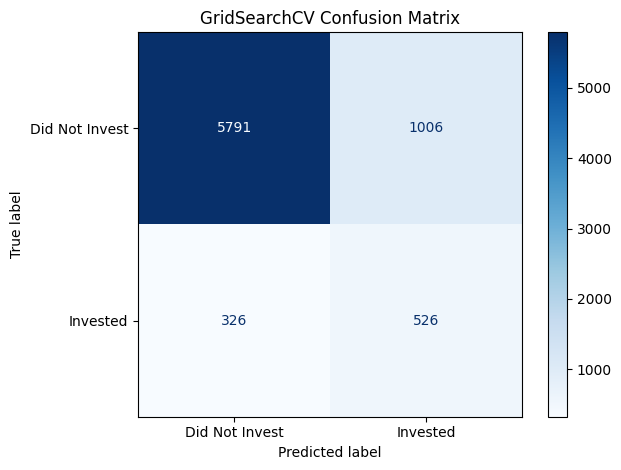

                precision    recall  f1-score   support

Did Not Invest       0.85      0.95      0.90      6117
      Invested       0.62      0.34      0.44      1532

      accuracy                           0.83      7649
     macro avg       0.73      0.65      0.67      7649
  weighted avg       0.81      0.83      0.81      7649



In [20]:
best_pipeline = grid_search.best_estimator_

y_pred_grid = best_pipeline.predict(X_test_log)
y_prob_grid = best_pipeline.predict_proba(X_test_log)[:, 1]

cm_grid = confusion_matrix(y_test_log, y_pred_grid)
disp_grid = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=['Did Not Invest', 'Invested'])
disp_grid.plot(cmap='Blues')
plt.title('GridSearchCV Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_pred_grid, y_test_log, target_names=['Did Not Invest', 'Invested']))

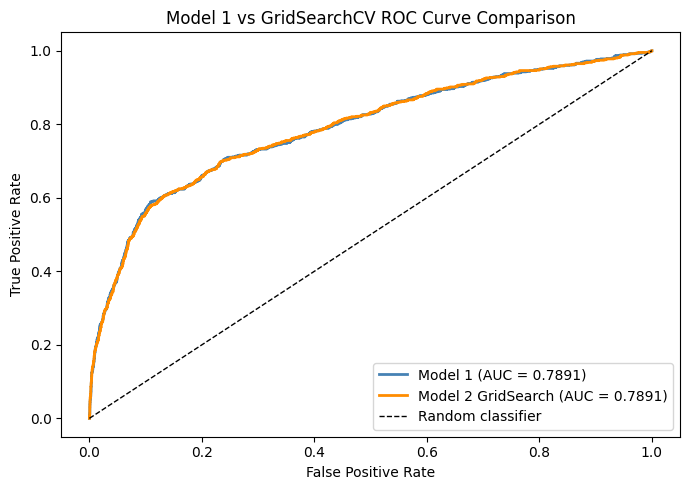

Model 1 ROC-AUC:  0.7891
Model 2 ROC-AUC:  0.7891


In [21]:
fpr_grid, tpr_grid, _ = roc_curve(y_test_log, y_prob_grid)
auc_grid = roc_auc_score(y_test_log, y_prob_grid)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc:.4f})')
ax.plot(fpr_grid, tpr_grid, lw=2, color='darkorange', label=f'Model 2 GridSearch (AUC = {auc_grid:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 vs GridSearchCV ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC:  {auc:.4f}")
print(f"Model 2 ROC-AUC:  {auc_grid:.4f}")

These models have exactly the same AUC score, showing us that the best parameters are likely close to our original selections. 

## Threshold tuning to GridSearchCV

Just as we did with Model 1, we can apply threshold tuning to Model 2 to try to produce a high level of recall. Using the same 0.35 threshold as a starting point, we can make a direct comparison across all three versions of the model.

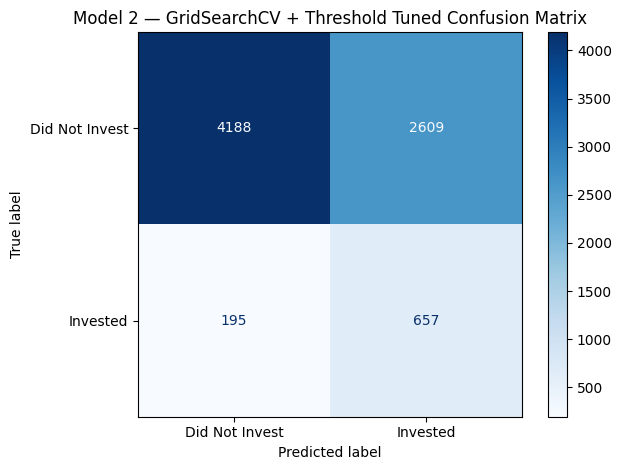

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [22]:
threshold = 0.35
y_pred_grid_tuned = (y_prob_grid >= threshold).astype(int)

cm_grid_tuned = confusion_matrix(y_test_log, y_pred_grid_tuned)
disp_grid_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_grid_tuned, display_labels=['Did Not Invest', 'Invested'])
disp_grid_tuned.plot(cmap='Blues')
plt.title('Model 2 — GridSearchCV + Threshold Tuned Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test_log, y_pred_grid_tuned, target_names=['Did Not Invest', 'Invested']))

## Final Logistic Regression Model Comparison

In [23]:
evaluate(y_test_log, y_pred_log,        "Model 1 — Default (threshold 0.5)")
evaluate(y_test_log, y_pred_log_tuned,  "Model 1 — Threshold Tuned (0.35)")
evaluate(y_test_log, y_pred_grid,       "Model 2 — GridSearchCV (threshold 0.5)")
evaluate(y_test_log, y_pred_grid_tuned, "Model 2 — GridSearchCV + Threshold Tuned (0.35)")


Model 1 — Default (threshold 0.5)
[[5806  991]
 [ 331  521]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      6797
           1       0.34      0.61      0.44       852

    accuracy                           0.83      7649
   macro avg       0.65      0.73      0.67      7649
weighted avg       0.88      0.83      0.85      7649


Model 1 — Threshold Tuned (0.35)
[[4268 2529]
 [ 203  649]]
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      6797
           1       0.20      0.76      0.32       852

    accuracy                           0.64      7649
   macro avg       0.58      0.69      0.54      7649
weighted avg       0.87      0.64      0.71      7649


Model 2 — GridSearchCV (threshold 0.5)
[[5791 1006]
 [ 326  526]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      6797
           1       0.34      0.62      0.44    

Our primary goal for this model was maximizing recall on the positive class (those who actually invested into the bank), since failing to identify someone who would actually invest is a much greater cost to the business than targeting a promotional call to a non-investor. The GridSearchCV model with threshold tuning has a recall of 0.77 on the invested class, correctly identifying 657 out of the 852 actual investors. The main tradeoff we accepted for this model was the very low precision of 0.20. This means that about every 1 in 5 customers who our flags will actually invest. However, this is an accetable tradeoff. We calculate the prevalence of the target variable below. 

In [24]:
print(y.value_counts(normalize=True))

y
0    0.888665
1    0.111335
Name: proportion, dtype: float64


This shows that only about 11% out of the total contacts invested, meaning a random targeting strategy would have a precision of around 0.11. Our model performing at 0.20 precision nearly doubles that baseline. So, combining this with a recall of 0.77, this represents a meaningful improvement in efficiency. 

Overall, the GridSearchCV provided only small gains to the model's performance, about 1% in recall, but the cross-validation was beneficial to ensure that our selected hyperparameters were able to generalize beyond the training data, rather than being optimized to a single train/test split. 